# Análise exploratória de dados

In [18]:
from utils import *

In [19]:
dataset_path = "Dados"
classes = os.listdir(dataset_path)

In [20]:
directories = {"Ant_D_D45L_PaMO" : "Dados/Ant_D_D45L_PaMO/", 
              "Ant_D_D45M_PaLO" : "Dados/Ant_D_D45M_PaLO/", 
              "Ant_D_DP10_PaDO" : "Dados/Ant_D_DP10_PaDO/", 
              "Ant_D_LM" : "Dados/Ant_D_LM/", 
              "Ant_E_D45L_PaMO" : "Dados/Ant_E_D45L_PaMO/", 
              "Ant_E_D45M_PaLO" : "Dados/Ant_E_D45M_PaLO/", 
              "Ant_E_DP10_PaDO" : "Dados/Ant_E_DP10_PaDO/", 
              "Ant_E_LM" : "Dados/Ant_E_LM/"}

---

## Distribuição visual de amostras por classe

In [22]:
def plot_images(directories):
    fig, axes = plt.subplots(2, 4, figsize=(10, 8))
    axes = axes.flatten()
    for ax, (cls, path) in zip(axes, directories.items()):
        img_name = next(
            f for f in os.listdir(path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        )
        img_path = os.path.join(path, img_name)

        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(cls)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [3]:
def corrigir_orientacao(img):
    try:
        for orientation in ExifTags.TAGS.keys():
            if ExifTags.TAGS[orientation] == 'Orientation':
                break
        exif = img._getexif()
        if exif is not None:
            orientation_value = exif.get(orientation, None)
            if orientation_value == 3:
                img = img.rotate(180, expand=True)
            elif orientation_value == 6:
                img = img.rotate(270, expand=True)
            elif orientation_value == 8:
                img = img.rotate(90, expand=True)
    except (AttributeError, KeyError, IndexError):
        pass
    return img

In [ ]:
def definir_orientacao(dataset_path):
    for subfolder in os.listdir(dataset_path):
        subfolder_path = os.path.join(dataset_path, subfolder)
        if os.path.isdir(subfolder_path):
            for img_name in os.listdir(subfolder_path):
                if img_name.lower().endswith((".jpg", ".jpeg", ".png")):
                    img_path = os.path.join(subfolder_path, img_name)
                    
                    img = Image.open(img_path)
                    img = corrigir_orientacao(img)
                    
                    img.save(img_path)
       
definir_orientacao(dataset_path)

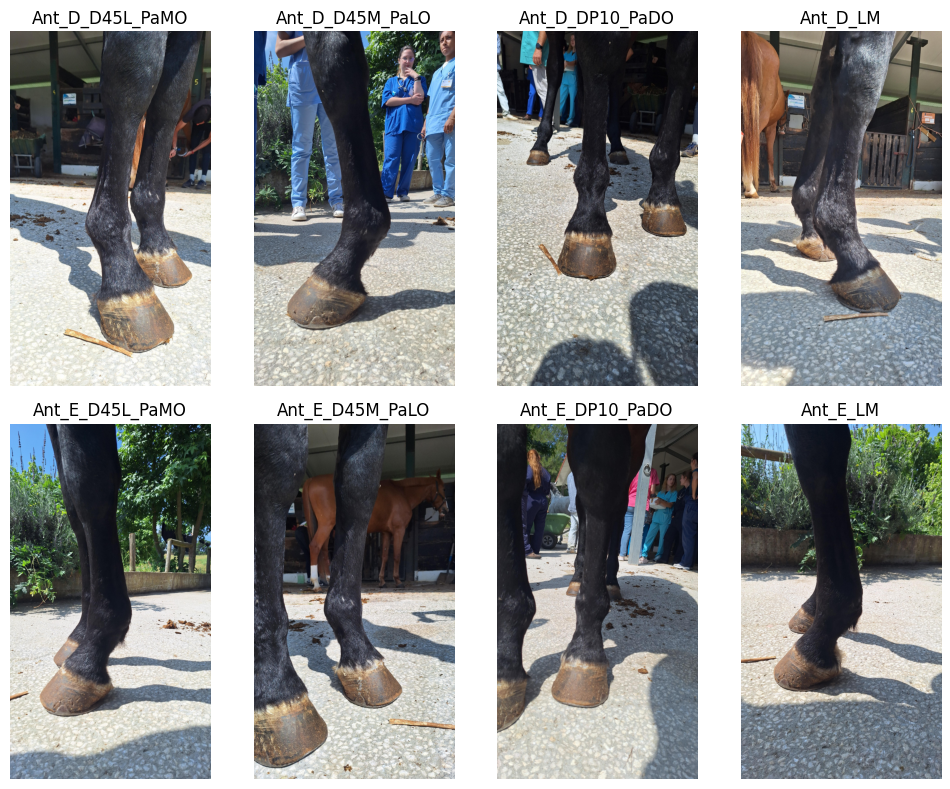

In [9]:
plot_images(directories)

In [18]:
split_data()

---

## Distribuição do número de imagens por classe

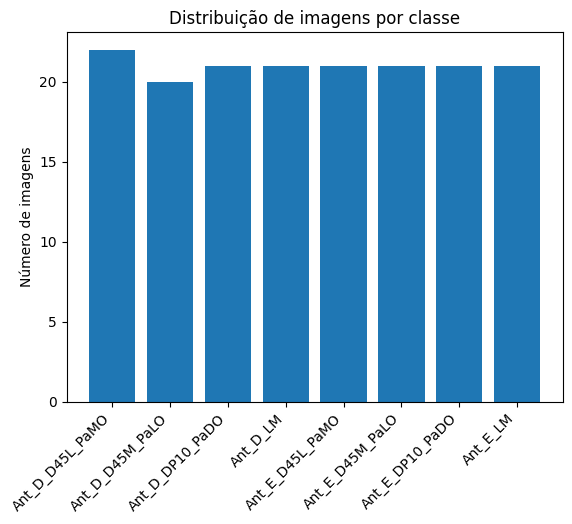

In [19]:
num_images = []
for path in directories.values():
    num_images.append(len(os.listdir(path)))
    
plt.bar(directories.keys(), num_images)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Número de imagens")
plt.title("Distribuição de imagens por classe")
plt.show()

---

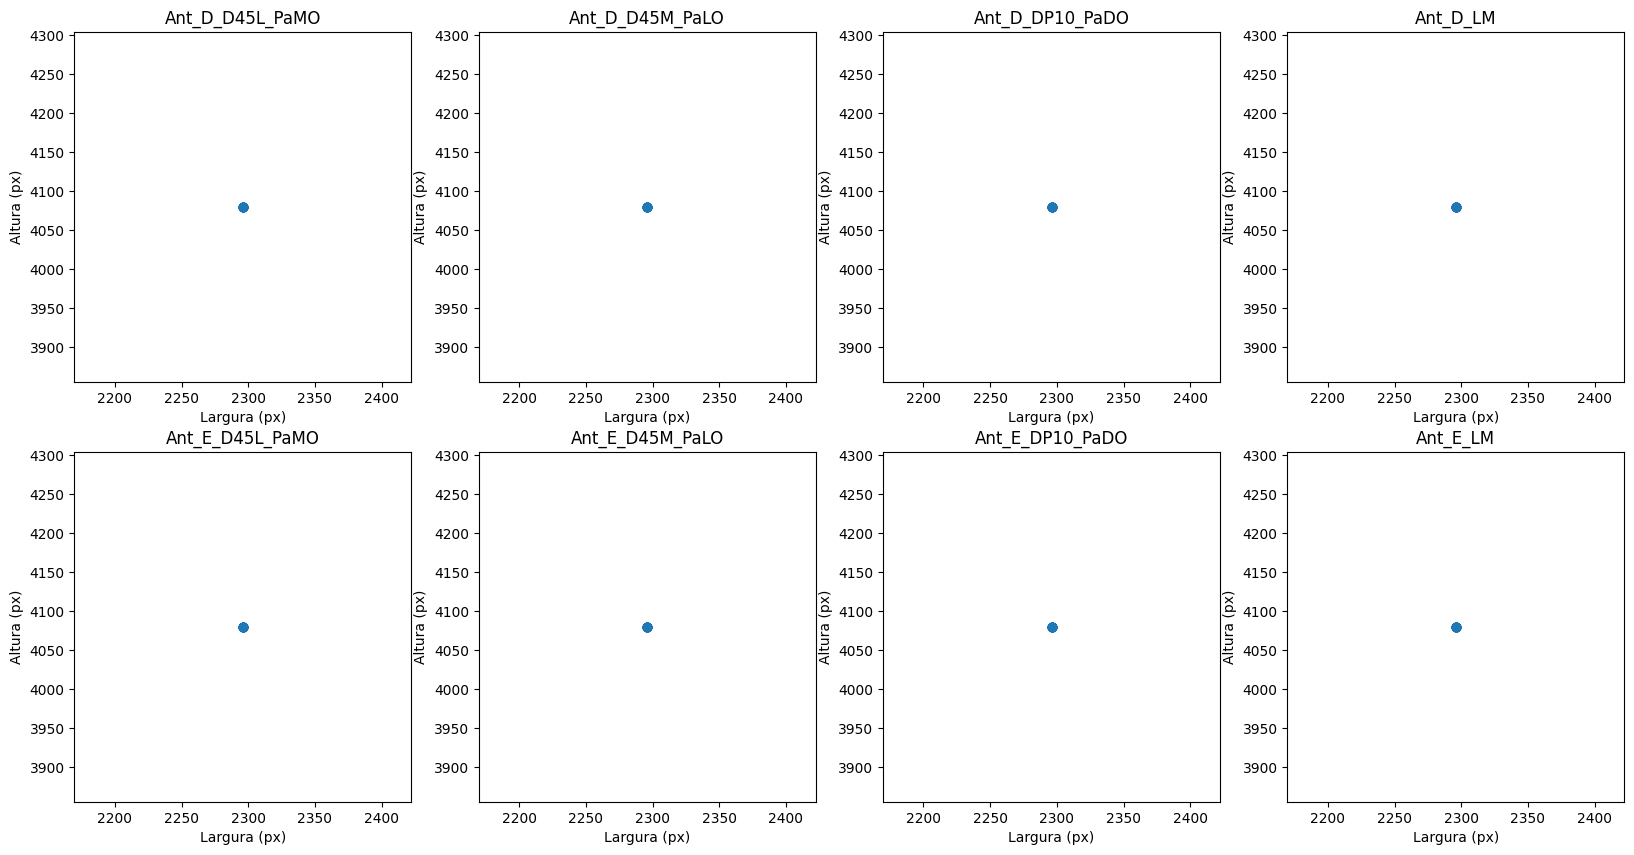

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, (classe, path) in zip(axes, directories.items()):
    altura = []
    largura = []
    for img_name in os.listdir(path):
        if img_name.lower().endswith((".jpg", ".jpeg", ".png")):
            with Image.open(path + img_name) as im:
                largura.append(im.size[0])
                altura.append(im.size[1])
    
    ax.scatter(largura, altura, label=classe)
    ax.set_title(classe)
    ax.set_xlabel("Largura (px)")
    ax.set_ylabel("Altura (px)")

---

## Organização dos dados de treino e teste

- dados_split

In [23]:
train_data = datasets.ImageFolder('dados_split/train', transform=transforms_0)
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_data = datasets.ImageFolder('dados_split/test', transform=transforms_0)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)
print(train_data.class_to_idx)
print(test_data.class_to_idx)

{'Ant_D_D45L_PaMO': 0, 'Ant_D_D45M_PaLO': 1, 'Ant_D_DP10_PaDO': 2, 'Ant_D_LM': 3, 'Ant_E_D45L_PaMO': 4, 'Ant_E_D45M_PaLO': 5, 'Ant_E_DP10_PaDO': 6, 'Ant_E_LM': 7}
{'Ant_D_D45L_PaMO': 0, 'Ant_D_D45M_PaLO': 1, 'Ant_D_DP10_PaDO': 2, 'Ant_D_LM': 3, 'Ant_E_D45L_PaMO': 4, 'Ant_E_D45M_PaLO': 5, 'Ant_E_DP10_PaDO': 6, 'Ant_E_LM': 7}


In [16]:
print(len(train_data))
labels = [label for _, label in train_data.samples]
print(Counter(labels))
print(len(train_loader.dataset) == len(train_data))

130
Counter({0: 17, 3: 17, 1: 16, 2: 16, 4: 16, 5: 16, 6: 16, 7: 16})
True


In [17]:
print(len(test_data))
labels = [label for _, label in test_data.samples]
print(Counter(labels))
print(len(test_loader.dataset) == len(test_data))

39
Counter({0: 5, 2: 5, 3: 5, 4: 5, 5: 5, 6: 5, 7: 5, 1: 4})
True


- dados_split2

In [24]:
train_data = datasets.ImageFolder('dados_split2/train', transform=transforms_0)
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_data = datasets.ImageFolder('dados_split2/test', transform=transforms_0)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

print(train_data.class_to_idx)
print(test_data.class_to_idx)

{'Ant_D45L_PaMO': 0, 'Ant_D45M_PaLO': 1, 'Ant_DP10_PaDO': 2, 'Ant_LM': 3}
{'Ant_D45L_PaMO': 0, 'Ant_D45M_PaLO': 1, 'Ant_DP10_PaDO': 2, 'Ant_LM': 3}


In [25]:
print(len(train_data))
labels = [label for _, label in train_data.samples]
print(Counter(labels))
print(len(train_loader.dataset) == len(train_data))

129
Counter({0: 33, 1: 32, 2: 32, 3: 32})
True


In [26]:
print(len(test_data))
labels = [label for _, label in test_data.samples]
print(Counter(labels))
print(len(test_loader.dataset) == len(test_data))

39
Counter({0: 10, 2: 10, 3: 10, 1: 9})
True


---